In [133]:
# install.packages('stringr')
library(mgcv)
library(itsadug)
library(report)
library(xtable)
library(stringr)
packageVersion("mgcv") # make sure that this is at least 1.8.32

[1] '1.9.1'

## Analysis: 1 Dialog Success
Fixed variables: dialog system and interaction of dialog system and linguistic adaptation

In [97]:
data = read.csv('chat_stats.tsv',sep='\t')

# set data types
data <- as.data.frame(unclass(data),
                      stringsAsFactors = TRUE)
#data$model_family <- relevel(data$model_family, ref="Flan-UL")
head(data)
summary(data)

,dialog_system,ling_style,chatbot_exp,length,success,sub_length,sub_success
,<fct>,<fct>,<int>,<int>,<int>,<int>,<int>
1,cts,ling_ad,3,7,1,2,1
2,cts,ling_ad,3,2,1,3,3
3,cts,ling_ad,3,5,1,3,3
4,cts,ling_ad,2,2,1,3,4
5,cts,ling_ad,2,4,1,3,4
6,cts,ling_ad,2,4,1,3,4


 dialog_system    ling_style   chatbot_exp        length          success      
 cts:125       baseline:188   Min.   :1.000   Min.   : 1.000   Min.   :0.0000  
 faq:126       ling_ad :191   1st Qu.:3.000   1st Qu.: 2.000   1st Qu.:0.0000  
 hdc:128                      Median :3.000   Median : 4.000   Median :1.0000  
                              Mean   :3.235   Mean   : 7.467   Mean   :0.6412  
                              3rd Qu.:4.000   3rd Qu.: 8.000   3rd Qu.:1.0000  
                              Max.   :5.000   Max.   :45.000   Max.   :1.0000  
   sub_length     sub_success   
 Min.   :1.000   Min.   :1.000  
 1st Qu.:2.000   1st Qu.:2.000  
 Median :3.000   Median :3.000  
 Mean   :2.792   Mean   :2.734  
 3rd Qu.:3.000   3rd Qu.:4.000  
 Max.   :5.000   Max.   :4.000  

In [108]:
model_formula <- success ~ dialog_system + ling_style
set.seed(0)
model <- bam(model_formula,
             data = data,
             family = binomial("logit"), # probit might also make sense: https://stats.stackexchange.com/questions/207625/how-to-choose-between-logit-probit-or-linear-probability-model
             method = "fREML",
             discrete = TRUE,
             select = TRUE,
             nthreads=1
             )
# Reports
summary(model)


Warning message in bam(model_formula, data = data, family = binomial("logit"), method = "fREML", :
"keine Gl"atten, ignoriere 'discrete=TRUE'"



Family: binomial 
Link function: logit 

Formula:
success ~ dialog_system + ling_style

Parametric coefficients:
                  Estimate Std. Error z value Pr(>|z|)    
(Intercept)         1.3836     0.2596   5.331 9.78e-08 ***
dialog_systemfaq   -1.1948     0.3023  -3.953 7.73e-05 ***
dialog_systemhdc   -1.6361     0.2991  -5.471 4.48e-08 ***
ling_styleling_ad   0.4560     0.2259   2.019   0.0435 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


R-sq.(adj) =  0.0882   Deviance explained = 7.89%
-REML = 350.94  Scale est. = 1         n = 379

In [109]:
# Wald tests (same as summary() for smooth terms, but different output for parametric terms)
set.seed(0)
model_anova <- anova(model)
print(model_anova)


Family: binomial 
Link function: logit 

Formula:
success ~ dialog_system + ling_style

Parametric Terms:
              df Chi.sq  p-value
dialog_system  2 30.281 2.66e-07
ling_style     1  4.077   0.0435



In [103]:
print(xtable(model_anova$pTerms.table))

% latex table generated in R 4.4.1 by xtable 1.8-4 package
% Thu Sep 12 14:03:56 2024
\begin{table}[ht]
\centering
\begin{tabular}{rrrr}
  \hline
 & df & Chi.sq & p-value \\ 
  \hline
dialog\_system & 2.00 & 30.28 & 0.00 \\ 
  ling\_style & 1.00 & 4.08 & 0.04 \\ 
   \hline
\end{tabular}
\end{table}


In [23]:
attributes(model_anova)

$names
 [1] "p.coeff"       "se"            "p.t"           "p.pv"         
 [5] "residual.df"   "m"             "chi.sq"        "s.pv"         
 [9] "scale"         "r.sq"          "family"        "formula"      
[13] "n"             "dev.expl"      "edf"           "dispersion"   
[17] "pTerms.pv"     "pTerms.chi.sq" "pTerms.df"     "cov.unscaled" 
[21] "cov.scaled"    "p.table"       "pTerms.table"  "s.table"      
[25] "method"        "sp.criterion"  "rank"          "np"           

$class
[1] "anova.gam"

In [110]:
print(report(model))

We fitted a logistic model (estimated using REML and outer optimizer) to
predict success with dialog_system and ling_style (formula: success ~
dialog_system + ling_style). The model's explanatory power is weak (R2 = 0.09).
The model's intercept, corresponding to dialog_system = cts and ling_style =
baseline, is at 1.38 (95% CI [0.87, 1.89], p < .001). Within this model:

  - The effect of dialog system [faq] is statistically significant and negative
(beta = -1.19, 95% CI [-1.79, -0.60], p < .001; Std. beta = -1.19, 95% CI
[-1.79, -0.60])
  - The effect of dialog system [hdc] is statistically significant and negative
(beta = -1.64, 95% CI [-2.22, -1.05], p < .001; Std. beta = -1.64, 95% CI
[-2.22, -1.05])
  - The effect of ling style [ling_ad] is statistically significant and positive
(beta = 0.46, 95% CI [0.01, 0.90], p = 0.043; Std. beta = 0.46, 95% CI [0.01,
0.90])

Standardized parameters were obtained by fitting the model on a standardized
version of the dataset.


## Subjective Length and Success

In [111]:
data = read.csv('chat_stats.tsv',sep='\t')

# set data types
data <- as.data.frame(unclass(data),
                      stringsAsFactors = TRUE)
#data$model_family <- relevel(data$model_family, ref="Flan-UL")
head(data)
summary(data)

,dialog_system,ling_style,chatbot_exp,length,success,sub_length,sub_success
,<fct>,<fct>,<int>,<int>,<int>,<int>,<int>
1,cts,ling_ad,3,7,1,2,1
2,cts,ling_ad,3,2,1,3,3
3,cts,ling_ad,3,5,1,3,3
4,cts,ling_ad,2,2,1,3,4
5,cts,ling_ad,2,4,1,3,4
6,cts,ling_ad,2,4,1,3,4


 dialog_system    ling_style   chatbot_exp        length          success      
 cts:125       baseline:188   Min.   :1.000   Min.   : 1.000   Min.   :0.0000  
 faq:126       ling_ad :191   1st Qu.:3.000   1st Qu.: 2.000   1st Qu.:0.0000  
 hdc:128                      Median :3.000   Median : 4.000   Median :1.0000  
                              Mean   :3.235   Mean   : 7.467   Mean   :0.6412  
                              3rd Qu.:4.000   3rd Qu.: 8.000   3rd Qu.:1.0000  
                              Max.   :5.000   Max.   :45.000   Max.   :1.0000  
   sub_length     sub_success   
 Min.   :1.000   Min.   :1.000  
 1st Qu.:2.000   1st Qu.:2.000  
 Median :3.000   Median :3.000  
 Mean   :2.792   Mean   :2.734  
 3rd Qu.:3.000   3rd Qu.:4.000  
 Max.   :5.000   Max.   :4.000  

In [132]:
model_formula <- sub_length ~ dialog_system + ling_style:dialog_system
set.seed(0)
model <- bam(model_formula,
             data = data,
             family = ocat(R = 5), # probit might also make sense: https://stats.stackexchange.com/questions/207625/how-to-choose-between-logit-probit-or-linear-probability-model
             method = "fREML",
             discrete = TRUE,
             select = TRUE,
             nthreads=1
             )
# Reports
summary(model)

Warning message in bam(model_formula, data = data, family = ocat(R = 5), method = "fREML", :
"keine Gl"atten, ignoriere 'discrete=TRUE'"



Family: Ordered Categorical(-1,0.53,3.27,5.14) 
Link function: identity 

Formula:
sub_length ~ dialog_system + ling_style:dialog_system

Parametric coefficients:
                                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)                          1.7175     0.2426   7.080 7.21e-12 ***
dialog_systemfaq                    -1.3991     0.3317  -4.218 3.09e-05 ***
dialog_systemhdc                     0.4485     0.3529   1.271   0.2045    
dialog_systemcts:ling_styleling_ad   0.3661     0.3374   1.085   0.2785    
dialog_systemfaq:ling_styleling_ad   0.8111     0.3231   2.510   0.0125 *  
dialog_systemhdc:ling_styleling_ad  -0.8648     0.3706  -2.334   0.0201 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


Deviance explained = 4.49%
-REML = 351.26  Scale est. = 1         n = 379

In [128]:
# Wald tests (same as summary() for smooth terms, but different output for parametric terms)
set.seed(0)
model_anova <- anova(model)
print(model_anova)


Family: Ordered Categorical(-1,0.01,1.37) 
Link function: identity 

Formula:
sub_success ~ dialog_system + ling_style

Parametric Terms:
              df     F  p-value
dialog_system  2 7.130 0.000914
ling_style     1 4.905 0.027379



In [129]:
print(report(model))

We fitted a general linear model (Ordered Categorical(-1,0.01,1.37) family with
a identity link) (estimated using REML and outer optimizer) to predict
sub_success with dialog_system and ling_style (formula: sub_success ~
dialog_system + ling_style). The model's explanatory power is weak
(Nagelkerke's R2 = 0.05). The model's intercept, corresponding to dialog_system
= cts and ling_style = baseline, is at 0.80 (95% CI [0.44, 1.17], p < .001).
Within this model:

  - The effect of dialog system [faq] is statistically significant and negative
(beta = -0.62, 95% CI [-1.06, -0.17], p = 0.007; Std. beta = -0.62, 95% CI
[-1.06, -0.17])
  - The effect of dialog system [hdc] is statistically significant and negative
(beta = -0.85, 95% CI [-1.30, -0.39], p < .001; Std. beta = -0.85, 95% CI
[-1.30, -0.39])
  - The effect of ling style [ling_ad] is statistically significant and positive
(beta = 0.41, 95% CI [0.05, 0.78], p = 0.027; Std. beta = 0.41, 95% CI [0.05,
0.78])

Standardized parameters wer

In [130]:
print(xtable(model_anova$pTerms.table))

% latex table generated in R 4.4.1 by xtable 1.8-4 package
% Thu Sep 12 16:57:04 2024
\begin{table}[ht]
\centering
\begin{tabular}{rrrr}
  \hline
 & df & F & p-value \\ 
  \hline
dialog\_system & 2.00 & 7.13 & 0.00 \\ 
  ling\_style & 1.00 & 4.91 & 0.03 \\ 
   \hline
\end{tabular}
\end{table}


## Mental Models

In [156]:
data = read.csv('user_usability.tsv',sep='\t')

# set data types
data <- as.data.frame(unclass(data),
                      stringsAsFactors = TRUE)
#data$model_family <- relevel(data$model_family, ref="Flan-UL")
head(data)
summary(data)

,username,agent,style,Accurate,Could.not.understand.answer,Disliked.everything,Easy.to.understand,Easy.to.use,Fast,Impersonal.Fixed.text,Interaction.too.long,Interaction.too.short,Liked.language.style,disliked_nothing
,<fct>,<fct>,<fct>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,4b9924c0c8ce326ac3c1e1688937c6,cts,baseline,0,1,0,0,0,1,0,0,0,0,0
2,e5de0b4b0679651ef175fceeb3413f,cts,baseline,0,1,0,0,0,0,0,0,0,0,0
3,7224eb019715bd25cc799d87862cf7,cts,baseline,0,1,0,0,0,1,0,0,0,0,0
4,2e4bd44563cdfd591a0a4bd566c308,cts,baseline,0,0,0,0,0,1,0,0,0,0,0
5,d9a101002e1d23b86bf785bab7b5e3,cts,baseline,0,0,0,1,0,0,1,0,0,0,0
6,273666715e559c45c6cc9a2e7f5033,cts,baseline,0,1,0,0,0,1,0,0,0,0,0


                           username   agent         style       Accurate      
 000650684db95bdac754d1c314c481:  1   cts:43   baseline:63   Min.   :0.00000  
 065a377639d60e104cfdd66f68e1db:  1   faq:43   ling_ad :65   1st Qu.:0.00000  
 09b1a7da8812a2efd58c0a1b92cc0b:  1   hdc:42                 Median :0.00000  
 0f7453ed7e2a7d60350698c1343c32:  1                          Mean   :0.07031  
 0f97158978beebaeb59f4dda0db17c:  1                          3rd Qu.:0.00000  
 109a7e62eb34a81bd913c0b17494b2:  1                          Max.   :1.00000  
 (Other)                       :122                                           
 Could.not.understand.answer Disliked.everything Easy.to.understand
 Min.   :0.0000              Min.   :0.0000      Min.   :0.0000    
 1st Qu.:0.0000              1st Qu.:0.0000      1st Qu.:0.0000    
 Median :0.0000              Median :0.0000      Median :0.0000    
 Mean   :0.3672              Mean   :0.0625      Mean   :0.1328    
 3rd Qu.:1.0000             

In [159]:
model_formula <- disliked_nothing ~ agent + style
set.seed(0)
model <- bam(model_formula,
             data = data,
             family = binomial("logit"), # probit might also make sense: https://stats.stackexchange.com/questions/207625/how-to-choose-between-logit-probit-or-linear-probability-model
             method = "fREML",
             discrete = TRUE,
             select = TRUE,
             nthreads=1
             )
# Reports
summary(model)

Warning message in bam(model_formula, data = data, family = binomial("logit"), method = "fREML", :
"keine Gl"atten, ignoriere 'discrete=TRUE'"



Family: binomial 
Link function: logit 

Formula:
disliked_nothing ~ agent + style

Parametric coefficients:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept)   -2.4134     0.5711  -4.226 2.38e-05 ***
agentfaq       0.1581     0.5629   0.281  0.77879    
agenthdc      -0.3199     0.6087  -0.526  0.59923    
styleling_ad   1.4946     0.5435   2.750  0.00596 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


R-sq.(adj) =  0.0483   Deviance explained = 7.95%
-REML = 117.19  Scale est. = 1         n = 128

In [160]:
# Wald tests (same as summary() for smooth terms, but different output for parametric terms)
set.seed(0)
model_anova <- anova(model)
print(model_anova)


Family: binomial 
Link function: logit 

Formula:
disliked_nothing ~ agent + style

Parametric Terms:
      df Chi.sq p-value
agent  2  0.646 0.72382
style  1  7.562 0.00596



In [161]:
print(xtable(model_anova$pTerms.table))

% latex table generated in R 4.4.1 by xtable 1.8-4 package
% Sun Sep 15 22:09:42 2024
\begin{table}[ht]
\centering
\begin{tabular}{rrrr}
  \hline
 & df & Chi.sq & p-value \\ 
  \hline
agent & 2.00 & 0.65 & 0.72 \\ 
  style & 1.00 & 7.56 & 0.01 \\ 
   \hline
\end{tabular}
\end{table}


In [162]:
print(report(model))

We fitted a logistic model (estimated using REML and outer optimizer) to
predict disliked_nothing with agent and style (formula: disliked_nothing ~
agent + style). The model's explanatory power is weak (R2 = 0.05). The model's
intercept, corresponding to agent = cts and style = baseline, is at -2.41 (95%
CI [-3.53, -1.29], p < .001). Within this model:

  - The effect of agent [faq] is statistically non-significant and positive (beta
= 0.16, 95% CI [-0.95, 1.26], p = 0.779; Std. beta = 0.16, 95% CI [-0.95,
1.26])
  - The effect of agent [hdc] is statistically non-significant and negative (beta
= -0.32, 95% CI [-1.51, 0.87], p = 0.599; Std. beta = -0.32, 95% CI [-1.51,
0.87])
  - The effect of style [ling_ad] is statistically significant and positive (beta
= 1.49, 95% CI [0.43, 2.56], p = 0.006; Std. beta = 1.49, 95% CI [0.43, 2.56])

Standardized parameters were obtained by fitting the model on a standardized
version of the dataset.


In [154]:
length(c(1,1,1,1,1,1,1))

[1] 7

In [74]:
# wald_gam(model, comp=list(model_family=levels(data$model_family)))
wald_gam(model, comp=list(model_family=levels(data$model_family), sd_prompting=1))

ERROR: Error in wald_gam(model, comp = list(model_family = levels(data$model_family), : model_family is not a modelterm.


Summary:
	* log_model_size : numeric predictor; with 100 values ranging from 7.903090 to 11.243038. 
	* text_length : numeric predictor; set to the value(s): 91. 
	* non_text_prompt_length : numeric predictor; set to the value(s): 198. 
	* model_family : factor; set to the value(s): Flan-T5. 
	* task : factor; set to the value(s): toxicity. 
	* NOTE : No random effects in the model to cancel.
 


Warning message in plot.window(...):
“"rug" ist kein Grafikparameter”
Warning message in plot.xy(xy, type, ...):
“"rug" ist kein Grafikparameter”
Warning message in axis(side = side, at = at, labels = labels, ...):
“"rug" ist kein Grafikparameter”
Warning message in axis(side = side, at = at, labels = labels, ...):
“"rug" ist kein Grafikparameter”
Warning message in box(...):
“"rug" ist kein Grafikparameter”
Warning message in title(...):
“"rug" ist kein Grafikparameter”



log_model_size window(s) of significant difference(s):
	8.982669 - 11.243038


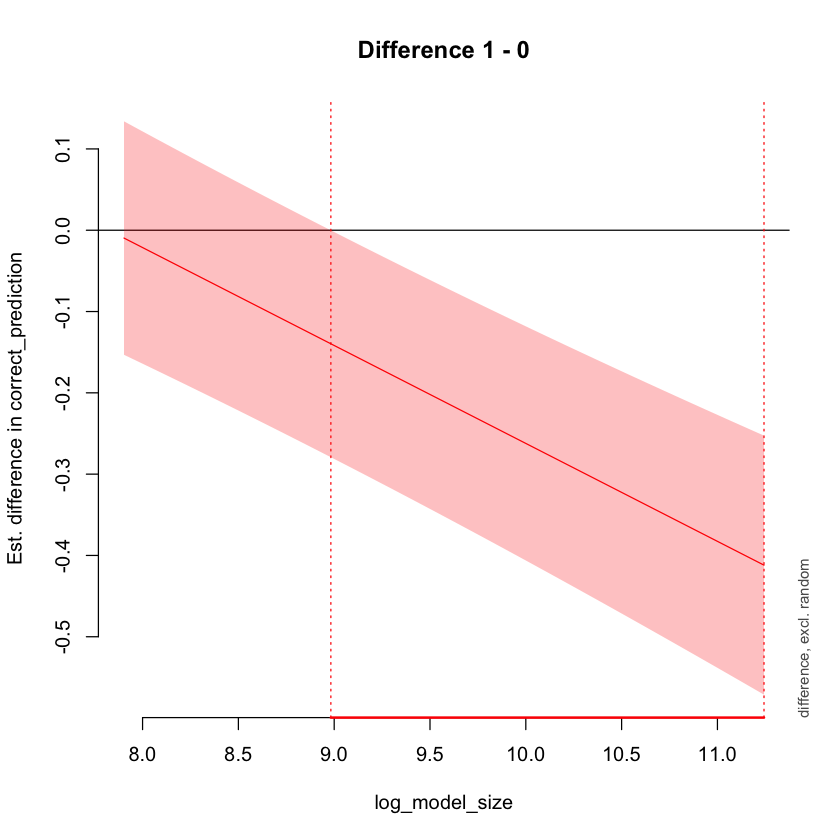

In [156]:
plot_diff(model, view="log_model_size",
            comp=list(sd_prompting=c(1,0)),
            col="red",
            rug=FALSE,
            #add=TRUE,
            rm.ranef=TRUE)

Summary:
	* log_model_size : numeric predictor; set to the value(s): 9.47712125471966. 
	* text_length : numeric predictor; with 100 values ranging from 7.000000 to 1343.000000. 
	* non_text_prompt_length : numeric predictor; set to the value(s): 198. 
	* model_family : factor; set to the value(s): Flan-T5. 
	* task : factor; set to the value(s): toxicity. 
	* NOTE : No random effects in the model to cancel.
 


Warning message in plot.window(...):
“"rug" ist kein Grafikparameter”
Warning message in plot.xy(xy, type, ...):
“"rug" ist kein Grafikparameter”
Warning message in axis(side = side, at = at, labels = labels, ...):
“"rug" ist kein Grafikparameter”
Warning message in axis(side = side, at = at, labels = labels, ...):
“"rug" ist kein Grafikparameter”
Warning message in box(...):
“"rug" ist kein Grafikparameter”
Warning message in title(...):
“"rug" ist kein Grafikparameter”



text_length window(s) of significant difference(s):
	7.000000 - 168.939394
	641.262626 - 1343.000000


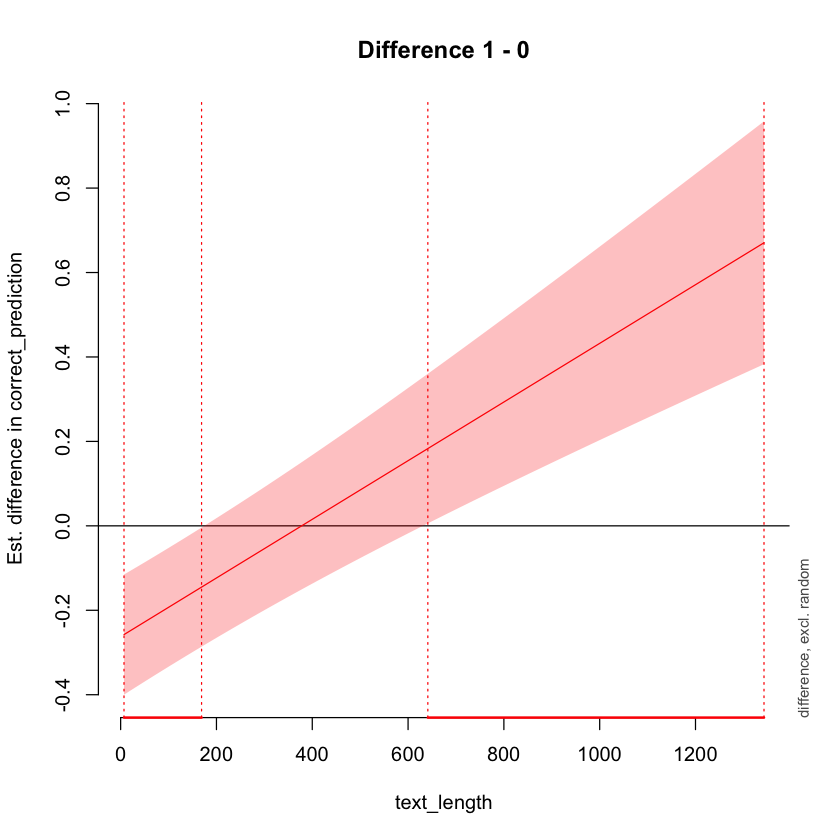

In [157]:
plot_diff(model, view="text_length",
            comp=list(sd_prompting=c(1,0)),
            col="red",
            rug=FALSE,
            #add=TRUE,
            rm.ranef=TRUE)

Summary:
	* log_model_size : numeric predictor; set to the value(s): 9.47712125471966. 
	* text_length : numeric predictor; set to the value(s): 91. 
	* non_text_prompt_length : numeric predictor; set to the value(s): 198. 
	* model_family : factor; set to the value(s): Dolly-V2, Flan-T5, Flan-UL, InstructGPT, OPT-IML, Tk-Instruct. 
	* task : factor; set to the value(s): toxicity. 
	* sd_prompting : numeric predictor; set to the value(s): 1. 
	* NOTE : No random effects in the model to cancel.
 


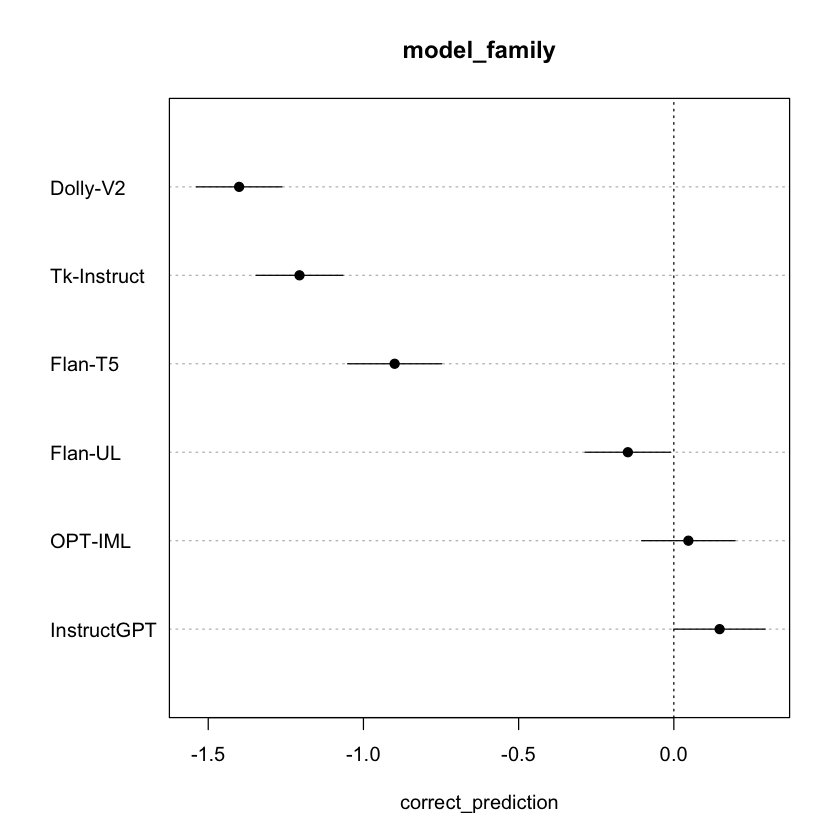

In [165]:
plot_parametric(model,  pred=list(model_family=levels(data$model_family)), cond=list(sd_prompting=c(1)),
    rm.ranef = TRUE)

## Analysis III: Zero Shot with Aggregated Predictions

### Data Loading

In [232]:
data = read.csv('data/zero_shot_aggregated_profiles.tsv',sep='\t')

# Decode B and M size strings, convert to millions
data$model_size <- str_replace(data$model_size, "175B", "175000000000")
data$model_size <- str_replace(data$model_size, "250M", "250000000")
data$model_size <- str_replace(data$model_size, "780M", "780000000")
data$model_size <- str_replace(data$model_size, "11B", "11000000000")
data$model_size <- str_replace(data$model_size, "20B", "20000000000")
data$model_size <- str_replace(data$model_size, "1.3B", "1300000000")
data$model_size <- str_replace(data$model_size, "30B", "30000000000")
data$model_size <- str_replace(data$model_size, "2.8B", "2800000000")
data$model_size <- str_replace(data$model_size, "6.9B", "6900000000")
data$model_size <- str_replace(data$model_size, "12B", "12000000000")
data$model_size <- str_replace(data$model_size, "3B", "3000000000")
data$model_size <- str_replace(data$model_size, "80M", "80000000")
data$model_size <- as.numeric(data$model_size)
data$log_model_size <- log10(data$model_size)
data$non_text_prompt_length <- data$mean_prompt_length - data$text_length

# set data types
data <- as.data.frame(unclass(data),
                      stringsAsFactors = TRUE)
# TODO: Make sure that the reference level for the binary variables is set correctly!
#data$sd_prompting <- as.factor(data$sd_prompting)
#data$sd_prompting <- relevel(data$sd_prompting, ref='0')

# This is needed to set the reference level in case there is a natural baseline level for a variable
#data$model_family <- relevel(data$model_family, ref=tail(names(sort(table(data$model_family))), 1))
data$sd_prompting <- as.factor(data$sd_prompting) # needed for contrasts with condition
data$model_family <- relevel(data$model_family, ref="Flan-UL")


In [233]:
head(data)
summary(data)

,model_name,model_family,model_size,task,dataset,instance_id,mean_prompt_length,std_prompt_length,text_length,sd_prompting,correct_prediction,original_dispersion,log_model_size,non_text_prompt_length
,<fct>,<fct>,<dbl>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<int>,<fct>,<int>,<dbl>,<dbl>,<dbl>
1,text-davinci-003,InstructGPT,1.75e+11,toxicity,diverse_perspectives,toxicity_diverse_perspectives_0,229,0,31,0,1,0.7,11.24304,198
2,text-davinci-003,InstructGPT,1.75e+11,toxicity,diverse_perspectives,toxicity_diverse_perspectives_1,247,0,49,0,1,0.7,11.24304,198
3,text-davinci-003,InstructGPT,1.75e+11,toxicity,diverse_perspectives,toxicity_diverse_perspectives_2,255,0,57,0,1,0.4,11.24304,198
4,text-davinci-003,InstructGPT,1.75e+11,toxicity,diverse_perspectives,toxicity_diverse_perspectives_3,292,0,94,0,0,0.8,11.24304,198
5,text-davinci-003,InstructGPT,1.75e+11,toxicity,diverse_perspectives,toxicity_diverse_perspectives_4,248,0,50,0,0,0.8,11.24304,198
6,text-davinci-003,InstructGPT,1.75e+11,toxicity,diverse_perspectives,toxicity_diverse_perspectives_5,293,0,95,0,1,0.4,11.24304,198


                             model_name          model_family  
 allenai-tk-instruct-11b-def-pos  : 13998   Flan-UL    :13998  
 allenai-tk-instruct-3b-def-pos   : 13998   Dolly-V2   :41994  
 allenai-tk-instruct-base-def-pos : 13998   Flan-T5    :69990  
 allenai-tk-instruct-large-def-pos: 13998   InstructGPT:13998  
 allenai-tk-instruct-small-def-pos: 13998   OPT-IML    :27996  
 databricks-dolly-v2-12b          : 13998   Tk-Instruct:69990  
 (Other)                          :153978                      
   model_size                task                       dataset     
 Min.   :8.000e+07   hatespeech:68000   diaz                :34000  
 1st Qu.:7.800e+08   sentiment :34000   diverse_perspectives:34000  
 Median :3.000e+09   stance    :67966   ghc                 :34000  
 Mean   :1.637e+10   toxicity  :68000   gwsd                :33966  
 3rd Qu.:1.100e+10                      jigsaw              :34000  
 Max.   :1.750e+11                      semeval2016t6       :34000  
     

### GAMM

In [234]:
model_formula <- correct_prediction ~   log_model_size +
                                        text_length +
                                        non_text_prompt_length +
                                        model_family +
                                        task +
                                        sd_prompting +
                                        # log_model_size:text_length +
                                        # log_model_size:non_text_prompt_length +
                                        # log_model_size:model_family +
                                        # log_model_size:task +
                                        log_model_size:sd_prompting +
                                        # text_length:non_text_prompt_length +
                                        # text_length:model_family +
                                        # text_length:task +
                                        text_length:sd_prompting +
                                        # non_text_prompt_length:model_family +
                                        # non_text_prompt_length:task +
                                        non_text_prompt_length:sd_prompting +
                                        # model_family:task +
                                        model_family:sd_prompting +
                                        task:sd_prompting +
                                        s(dataset, bs = "re")
     
set.seed(0)
model <- bam(model_formula,
             data = data,
             family = binomial("logit"), # probit might also make sense: https://stats.stackexchange.com/questions/207625/how-to-choose-between-logit-probit-or-linear-probability-model
             method = "fREML",
             discrete = TRUE,
             select = TRUE,
             nthreads=12
             )


# Save the model and its dependencies
saveRDS(model, "models/model_zero_shot_aggregated.rds")
dependencies = c("mgcv")
file_obj <- file("models/model_zero_shot_aggregated.dep")
writeLines(dependencies, file_obj)
close(file_obj)

# Reports
summary(model)



Family: binomial 
Link function: logit 

Formula:
correct_prediction ~ log_model_size + text_length + non_text_prompt_length + 
    model_family + task + sd_prompting + log_model_size:sd_prompting + 
    text_length:sd_prompting + non_text_prompt_length:sd_prompting + 
    model_family:sd_prompting + task:sd_prompting + s(dataset, 
    bs = "re")

Parametric coefficients:
                                        Estimate Std. Error z value Pr(>|z|)
(Intercept)                           -6.916e-01  2.887e-01  -2.396 0.016584
log_model_size                         1.712e-02  9.737e-03   1.758 0.078758
text_length                            1.285e-04  5.073e-05   2.534 0.011291
non_text_prompt_length                -8.383e-04  9.201e-04  -0.911 0.362248
model_familyDolly-V2                  -1.212e-01  3.188e-02  -3.801 0.000144
model_familyFlan-T5                    2.094e-01  3.234e-02   6.474 9.53e-11
model_familyInstructGPT                1.659e+00  3.893e-02  42.632  < 2e-16
model_fa

In [235]:
# print(concurvity(model, full = FALSE))

In [236]:
# Wald tests (same as summary() for smooth terms, but different output for parametric terms)
set.seed(0)
model_anova <- anova(model)
print(model_anova)


Family: binomial 
Link function: logit 

Formula:
correct_prediction ~ log_model_size + text_length + non_text_prompt_length + 
    model_family + task + sd_prompting + log_model_size:sd_prompting + 
    text_length:sd_prompting + non_text_prompt_length:sd_prompting + 
    model_family:sd_prompting + task:sd_prompting + s(dataset, 
    bs = "re")

Parametric Terms:
                                    df   Chi.sq  p-value
log_model_size                       1    3.090 0.078758
text_length                          1    6.419 0.011291
non_text_prompt_length               1    0.830 0.362248
model_family                         5 6470.727  < 2e-16
task                                 3   18.312 0.000379
sd_prompting                         1   45.399 1.61e-11
log_model_size:sd_prompting          1   30.040 4.23e-08
text_length:sd_prompting             1    2.793 0.094670
non_text_prompt_length:sd_prompting  1   26.836 2.22e-07
model_family:sd_prompting            5  101.286  < 2e-16
task

In [237]:
# LateX tables
#anova_parametric <- model_anova$pTerms.table
#print(xtable(anova_parametric, type = "latex",
#            label="",
#            caption="Statistics for zero shot with original sociodemographic profiles: parametric terms"),
#      #file = "tables/gamm_correctness_zero_shot_original_parametric.tex"
#     )

In [238]:
#anova_smooth <- model_anova$s.table
#print(xtable(anova_smooth, type = "latex",
#            label="",
#            caption="Statistics for zero shot with original sociodemographic profiles: smooth terms"),
#      #file = "tables/gamm_correctness_zero_shot_original_smooth.tex"
#     )

In [239]:
print(report(model))

We fitted a logistic model (estimated using fREML and perf optimizer) to
predict correct_prediction with log_model_size, text_length,
non_text_prompt_length, model_family, task, sd_prompting and dataset (formula:
correct_prediction ~ log_model_size + text_length + non_text_prompt_length +
model_family + task + sd_prompting + log_model_size:sd_prompting +
text_length:sd_prompting + non_text_prompt_length:sd_prompting +
model_family:sd_prompting + task:sd_prompting + s(dataset, bs = "re")). The
model's explanatory power is weak (R2 = 0.12). The model's intercept,
corresponding to log_model_size = 0, text_length = 0, non_text_prompt_length =
0, model_family = Flan-UL, task = hatespeech, sd_prompting = 0 and dataset =
diaz, is at -0.69 (95% CI [-1.26, -0.13], p = 0.017). Within this model:

  - The effect of log model size is statistically non-significant and positive
(beta = 0.02, 95% CI [-1.97e-03, 0.04], p = 0.079; Std. beta = 0.02, 95% CI
[-1.78e-03, 0.03])
  - The effect of text lengt

In [240]:
print(xtable(model_anova$pTerms.table))

% latex table generated in R 4.2.3 by xtable 1.8-4 package
% Sat Sep  9 21:00:24 2023
\begin{table}[ht]
\centering
\begin{tabular}{rrrr}
  \hline
 & df & Chi.sq & p-value \\ 
  \hline
log\_model\_size & 1.00 & 3.09 & 0.08 \\ 
  text\_length & 1.00 & 6.42 & 0.01 \\ 
  non\_text\_prompt\_length & 1.00 & 0.83 & 0.36 \\ 
  model\_family & 5.00 & 6470.73 & 0.00 \\ 
  task & 3.00 & 18.31 & 0.00 \\ 
  sd\_prompting & 1.00 & 45.40 & 0.00 \\ 
  log\_model\_size:sd\_prompting & 1.00 & 30.04 & 0.00 \\ 
  text\_length:sd\_prompting & 1.00 & 2.79 & 0.09 \\ 
  non\_text\_prompt\_length:sd\_prompting & 1.00 & 26.84 & 0.00 \\ 
  model\_family:sd\_prompting & 5.00 & 101.29 & 0.00 \\ 
  task:sd\_prompting & 3.00 & 309.46 & 0.00 \\ 
   \hline
\end{tabular}
\end{table}


In [241]:
wald_gam(model, comp=list(model_family=levels(data$model_family), sd_prompting=1))


Wald test
-----
model: correct_prediction ~ log_model_size + text_length + non_text_prompt_length + 
    model_family + task + sd_prompting + log_model_size:sd_prompting + 
    text_length:sd_prompting + non_text_prompt_length:sd_prompting + 
    model_family:sd_prompting + task:sd_prompting + s(dataset, 
    bs = "re")

Parametric effects:
                          (Intercept)                        log_model_size 
                        -0.6916380299                          0.0171165234 
                          text_length                non_text_prompt_length 
                         0.0001285325                         -0.0008382987 
                 model_familyDolly-V2                   model_familyFlan-T5 
                        -0.1211672255                          0.2093536270 
              model_familyInstructGPT                   model_familyOPT-IML 
                         1.6594805064                          1.2569675286 
              model_familyTk-Instruct   

In [242]:
wald_gam(model, comp=list(task=levels(data$task), sd_prompting=1))


Wald test
-----
model: correct_prediction ~ log_model_size + text_length + non_text_prompt_length + 
    model_family + task + sd_prompting + log_model_size:sd_prompting + 
    text_length:sd_prompting + non_text_prompt_length:sd_prompting + 
    model_family:sd_prompting + task:sd_prompting + s(dataset, 
    bs = "re")

Parametric effects:
                          (Intercept)                        log_model_size 
                        -0.6916380299                          0.0171165234 
                          text_length                non_text_prompt_length 
                         0.0001285325                         -0.0008382987 
                 model_familyDolly-V2                   model_familyFlan-T5 
                        -0.1211672255                          0.2093536270 
              model_familyInstructGPT                   model_familyOPT-IML 
                         1.6594805064                          1.2569675286 
              model_familyTk-Instruct   

In [223]:
# shift <- coef(model)[1]
# plot(model,
#     #select=i,
#     pages = 0,
#     rug = TRUE,
#     residuals = FALSE,
#     shade = TRUE,
#     #col="blue",
#     shade.col = "gray90",
#     seWithMean = TRUE,
#     shift=shift,
#     scale=0,
#     all.terms = TRUE,
#     scheme = 2,
#     contour.col = "black",
#     #lwd=3,
#     #main=new_title,
#     #xlab=covariates2plottitles[[all_plots[[i]]$xlab]],
#     #ylab=new_y_label
# )

In [224]:
# plot_smooth(model, view="log_model_size",
#             cond=list(sd_prompting=c(0)),
#             col="red",
#             rug=FALSE,
#             #add=TRUE,
#             rm.ranef=TRUE)
# plot_smooth(model, view="log_model_size",
#             cond=list(sd_prompting=c(1)),
#             col="blue",
#             rug=FALSE,
#             add=TRUE,
#             rm.ranef=TRUE)

In [193]:
# plot_diff(model, view="log_model_size",
#             comp=list(sd_prompting=c(1,0)),
#             col="red",
#             rug=FALSE,
#             #add=TRUE,
#             rm.ranef=TRUE)

In [194]:
# plot_diff(model, view="text_length",
#             comp=list(sd_prompting=c(1,0)),
#             col="red",
#             rug=FALSE,
#             #add=TRUE,
#             rm.ranef=TRUE)

In [178]:
# contrasts
# wald_gam(model, comp=list(sd_prompting=levels(data$sd_prompting), model_family="Flan-UL"))
# wald_gam(model, comp=list(sd_prompting=levels(data$sd_prompting), model_family="Flan-T5"))
# wald_gam(model, comp=list(sd_prompting=levels(data$sd_prompting), model_family="InstructGPT"))
# wald_gam(model, comp=list(sd_prompting=levels(data$sd_prompting), model_family="OPT-IML"))
# wald_gam(model, comp=list(sd_prompting=levels(data$sd_prompting), model_family="Tk-Instruct"))
# wald_gam(model, comp=list(sd_prompting=levels(data$sd_prompting), model_family="Dolly-V2"))

In [296]:
#diff <- get_difference(model, comp=list(sd_prompting=levels(data$sd_prompting)), cond=list(model_family="Flan-UL"))
#print(diff)

## Analysis IV: Disagreement Prediction

In [243]:
data = read.csv('data/disagreement_detection.tsv',sep='\t')

# Decode B and M size strings, convert to millions
data$model_size <- str_replace(data$model_size, "175B", "175000000000")
data$model_size <- str_replace(data$model_size, "250M", "250000000")
data$model_size <- str_replace(data$model_size, "780M", "780000000")
data$model_size <- str_replace(data$model_size, "11B", "11000000000")
data$model_size <- str_replace(data$model_size, "20B", "20000000000")
data$model_size <- str_replace(data$model_size, "1.3B", "1300000000")
data$model_size <- str_replace(data$model_size, "30B", "30000000000")
data$model_size <- str_replace(data$model_size, "2.8B", "2800000000")
data$model_size <- str_replace(data$model_size, "6.9B", "6900000000")
data$model_size <- str_replace(data$model_size, "12B", "12000000000")
data$model_size <- str_replace(data$model_size, "3B", "3000000000")
data$model_size <- str_replace(data$model_size, "80M", "80000000")
data$model_size <- as.numeric(data$model_size)
data$log_model_size <- log10(data$model_size)
data$non_text_prompt_length <- data$mean_prompt_length - data$text_length
# set data types
data <- as.data.frame(unclass(data),
                      stringsAsFactors = TRUE)
data$model_family <- relevel(data$model_family, ref="Flan-UL")
head(data)
summary(data)

,model_name,model_family,model_size,task,dataset,instance_id,mean_prompt_length,std_prompt_length,text_length,correct_prediction,original_dispersion,prompting_dispersion,log_model_size,non_text_prompt_length
,<fct>,<fct>,<dbl>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
1,text-davinci-003,InstructGPT,1.75e+11,toxicity,diverse_perspectives,toxicity_diverse_perspectives_0,344.0,6.723095,31,0,0.7,0,11.24304,313.0
2,text-davinci-003,InstructGPT,1.75e+11,toxicity,diverse_perspectives,toxicity_diverse_perspectives_1,385.8,15.778466,49,0,0.7,0,11.24304,336.8
3,text-davinci-003,InstructGPT,1.75e+11,toxicity,diverse_perspectives,toxicity_diverse_perspectives_2,383.2,21.958142,57,0,0.4,0,11.24304,326.2
4,text-davinci-003,InstructGPT,1.75e+11,toxicity,diverse_perspectives,toxicity_diverse_perspectives_3,420.0,14.505171,94,0,0.8,0,11.24304,326.0
5,text-davinci-003,InstructGPT,1.75e+11,toxicity,diverse_perspectives,toxicity_diverse_perspectives_4,388.2,19.260322,50,0,0.8,0,11.24304,338.2
6,text-davinci-003,InstructGPT,1.75e+11,toxicity,diverse_perspectives,toxicity_diverse_perspectives_5,428.6,14.677875,95,0,0.4,0,11.24304,333.6


                             model_name         model_family  
 allenai-tk-instruct-11b-def-pos  : 6999   Flan-UL    : 6999  
 allenai-tk-instruct-3b-def-pos   : 6999   Dolly-V2   :20997  
 allenai-tk-instruct-base-def-pos : 6999   Flan-T5    :34995  
 allenai-tk-instruct-large-def-pos: 6999   InstructGPT: 6999  
 allenai-tk-instruct-small-def-pos: 6999   OPT-IML    :13998  
 databricks-dolly-v2-12b          : 6999   Tk-Instruct:34995  
 (Other)                          :76989                      
   model_size                task                       dataset     
 Min.   :8.000e+07   hatespeech:34000   diaz                :17000  
 1st Qu.:7.800e+08   sentiment :17000   diverse_perspectives:17000  
 Median :3.000e+09   stance    :33983   ghc                 :17000  
 Mean   :1.637e+10   toxicity  :34000   gwsd                :16983  
 3rd Qu.:1.100e+10                      jigsaw              :17000  
 Max.   :1.750e+11                      semeval2016t6       :17000  
             

In [244]:
# correct_prediction means correct disagreement prediction here
model_formula <- correct_prediction ~   log_model_size +
                                        text_length +
                                        non_text_prompt_length +
                                        model_family +
                                        task +
                                        # log_model_size:text_length +
                                        # log_model_size:non_text_prompt_length +
                                        # log_model_size:model_family +
                                        # log_model_size:task +
                                        # text_length:non_text_prompt_length +
                                        # text_length:model_family +
                                        # text_length:task +
                                        # non_text_prompt_length:model_family +
                                        # non_text_prompt_length:task +
                                        # model_family:task +
                                        s(dataset, bs = "re")
     
set.seed(0)
model <- bam(model_formula,
             data = data,
             family = binomial("logit"), # probit might also make sense: https://stats.stackexchange.com/questions/207625/how-to-choose-between-logit-probit-or-linear-probability-model
             method = "fREML",
             discrete = TRUE,
             select = TRUE,
             nthreads=12
             )


# Save the model and its dependencies
saveRDS(model, "models/disagreement.rds")
dependencies = c("mgcv")
file_obj <- file("models/disagreement.dep")
writeLines(dependencies, file_obj)
close(file_obj)

# Reports
summary(model)



Family: binomial 
Link function: logit 

Formula:
correct_prediction ~ log_model_size + text_length + non_text_prompt_length + 
    model_family + task + s(dataset, bs = "re")

Parametric coefficients:
                          Estimate Std. Error z value Pr(>|z|)    
(Intercept)             -2.219e+00  4.128e-01  -5.375 7.68e-08 ***
log_model_size           2.240e-01  9.431e-03  23.755  < 2e-16 ***
text_length             -2.717e-04  5.056e-05  -5.374 7.72e-08 ***
non_text_prompt_length   7.359e-04  8.768e-04   0.839   0.4013    
model_familyDolly-V2     5.818e-01  3.028e-02  19.212  < 2e-16 ***
model_familyFlan-T5      5.251e-01  2.997e-02  17.519  < 2e-16 ***
model_familyInstructGPT  2.940e-02  3.599e-02   0.817   0.4140    
model_familyOPT-IML      3.041e-01  3.065e-02   9.922  < 2e-16 ***
model_familyTk-Instruct  3.956e-01  2.995e-02  13.207  < 2e-16 ***
tasksentiment           -1.065e+00  5.501e-01  -1.936   0.0529 .  
taskstance              -9.314e-01  4.499e-01  -2.070   0.03

In [245]:
# Wald tests (same as summary() for smooth terms, but different output for parametric terms)
set.seed(0)
model_anova <- anova(model)
print(model_anova)


Family: binomial 
Link function: logit 

Formula:
correct_prediction ~ log_model_size + text_length + non_text_prompt_length + 
    model_family + task + s(dataset, bs = "re")

Parametric Terms:
                       df  Chi.sq  p-value
log_model_size          1 564.285  < 2e-16
text_length             1  28.876 7.72e-08
non_text_prompt_length  1   0.704    0.401
model_family            5 579.842  < 2e-16
task                    3   5.921    0.116

Approximate significance of smooth terms:
             edf Ref.df Chi.sq p-value
s(dataset) 2.976  5.000  138.1  <2e-16


In [246]:
print(xtable(model_anova$pTerms.table))

% latex table generated in R 4.2.3 by xtable 1.8-4 package
% Sat Sep  9 23:08:15 2023
\begin{table}[ht]
\centering
\begin{tabular}{rrrr}
  \hline
 & df & Chi.sq & p-value \\ 
  \hline
log\_model\_size & 1.00 & 564.29 & 0.00 \\ 
  text\_length & 1.00 & 28.88 & 0.00 \\ 
  non\_text\_prompt\_length & 1.00 & 0.70 & 0.40 \\ 
  model\_family & 5.00 & 579.84 & 0.00 \\ 
  task & 3.00 & 5.92 & 0.12 \\ 
   \hline
\end{tabular}
\end{table}


In [247]:
print(report(model))

We fitted a logistic model (estimated using fREML and perf optimizer) to
predict correct_prediction with log_model_size, text_length,
non_text_prompt_length, model_family, task and dataset (formula:
correct_prediction ~ log_model_size + text_length + non_text_prompt_length +
model_family + task + s(dataset, bs = "re")). The model's explanatory power is
weak (R2 = 0.06). The model's intercept, corresponding to log_model_size = 0,
text_length = 0, non_text_prompt_length = 0, model_family = Flan-UL, task =
hatespeech and dataset = diaz, is at -2.22 (95% CI [-3.03, -1.41], p < .001).
Within this model:

  - The effect of log model size is statistically significant and positive (beta
= 0.22, 95% CI [0.21, 0.24], p < .001; Std. beta = 0.20, 95% CI [0.19, 0.22])
  - The effect of text length is statistically significant and negative (beta =
-2.72e-04, 95% CI [-3.71e-04, -1.73e-04], p < .001; Std. beta = -0.04, 95% CI
[-0.05, -0.02])
  - The effect of non text prompt length is statistically no

In [248]:
wald_gam(model, comp=list(model_family=levels(data$model_family)))


Wald test
-----
model: correct_prediction ~ log_model_size + text_length + non_text_prompt_length + 
    model_family + task + s(dataset, bs = "re")

Parametric effects:
            (Intercept)          log_model_size             text_length 
          -2.2187640764            0.2240187011           -0.0002717079 
 non_text_prompt_length    model_familyDolly-V2     model_familyFlan-T5 
           0.0007358980            0.5817810668            0.5251172520 
model_familyInstructGPT     model_familyOPT-IML model_familyTk-Instruct 
           0.0294036107            0.3040646506            0.3955996987 
          tasksentiment              taskstance            tasktoxicity 
          -1.0648120740           -0.9313697587           -0.4040103149 

Null hypothesis =  0 

Comparing Dolly-V2 with InstructGPT (hatespeech):
	X2(1.000) = 284.390, p < 2e-16 ***

Comparing Flan-T5 with InstructGPT (hatespeech):
	X2(1.000) = 205.568, p < 2e-16 ***

Comparing Dolly-V2 with OPT-IML (hatespeech):
	X